# 📝 Ejercicio Guiado — Regresión Lineal: Predicción de Ganancias en Startups

**Nombre:** Thomas Osorio Zambrano
**Fecha:** 24 de febrero de 2026

---

En este ejercicio construirás un modelo de **Regresión Lineal** para predecir las ganancias (`Profit`) de startups en distintos estados de EE.UU., a partir de sus gastos en I+D, administración y marketing.

Seguirás los mismos pasos del notebook que revisamos en clase, pero con algunas variaciones importantes en el preprocesamiento:

| Paso | Notebook que vimos | **Este ejercicio** |
|---|---|---|
| Escalado numérico | `StandardScaler` | **`MinMaxScaler`** |
| Variable categórica | `OneHotEncoder` | **`OrdinalEncoder`** |
| Predicción final | — | **Muestra sintética propia** |

El dataset proviene de Kaggle:  
📦 [Startup - Multiple Linear Regression](https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression)

Contiene información de **50 startups** con las siguientes columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `R&D Spend` | Numérica | Gasto en Investigación y Desarrollo (USD) |
| `Administration` | Numérica | Gasto en Administración (USD) |
| `Marketing Spend` | Numérica | Gasto en Marketing (USD) |
| `State` | Categórica | Estado de EE.UU. (New York, California, Florida) |
| `Profit` | Numérica 🎯 | **Variable objetivo** — Ganancia de la startup (USD) |

> 💡 **Recuerda:** como `Profit` es una variable continua (un número real), este es un problema de **regresión**, no de clasificación.

## 0. Descarga del dataset

Descarga el archivo `50_Startups.csv` desde Kaggle y súbelo a la misma carpeta del notebook.

**Opción A – Kaggle API:**
```bash
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d karthickveerakumar/startup-logistic-regression --unzip
```

**Opción B – Descarga manual:**  
Descarga `50_Startups.csv` desde la página de Kaggle y súbelo a este entorno.

**Opción C – Datos sintéticos** *(si no tienes acceso a Kaggle)*:  
Por si no tienes acceso a Kaggle, el profesor subirá el dataset a la carpeta Lecture_06/notebooks/data 

In [4]:
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d karthickveerakumar/startup-logistic-regression --unzip

cp: kaggle.json: No such file or directory
Dataset URL: https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression
License(s): unknown
100%|██████████████████████████████████████| 1.30k/1.30k [00:00<00:00, 2.42MB/s]



## 1. Importación de librerías

Importa todas las librerías que necesitarás a lo largo del ejercicio.

**Pistas:**
- Necesitarás `numpy` y `pandas` para manipular datos
- De `sklearn.model_selection` importa la función para dividir train/test
- De `sklearn.pipeline` importa `Pipeline`
- De `sklearn.compose` importa `ColumnTransformer`
- De `sklearn.preprocessing` importa **`MinMaxScaler`** y **`OrdinalEncoder`** *(ojo: no StandardScaler ni OneHotEncoder esta vez)*
- De `sklearn.impute` importa `SimpleImputer`
- De `sklearn.linear_model` importa `LinearRegression`
- De `sklearn.metrics` importa `mean_absolute_error`, `mean_squared_error` y `r2_score`
- Importa `matplotlib.pyplot` para graficar

> 💡 **¿Qué es MinMaxScaler?**  
> Transforma cada variable numérica al rango **[0, 1]** aplicando la siguiente fórmula a cada valor:  
> `x_scaled = (x - x_min) / (x_max - x_min)`  
> A diferencia de `StandardScaler` que centra los datos en 0 con desviación estándar 1, `MinMaxScaler` **preserva la forma de la distribución** y garantiza un rango acotado. Es útil cuando el algoritmo es sensible a la magnitud de los valores.

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt



## 2. Carga de datos

Carga el archivo `50_Startups.csv` y haz una exploración inicial completa.

**Pistas:**
- Usa `pd.read_csv(...)` para cargar el archivo
- Usa `.shape` para ver las dimensiones
- Usa `.head()` para ver las primeras filas
- Usa `.info()` o `.dtypes` para ver los tipos de cada columna
- Usa `.describe()` para estadísticos básicos de columnas numéricas
- Usa `.isnull().sum()` para detectar valores nulos
- Usa `.value_counts()` sobre la columna `State` para ver cuántas startups hay por estado

In [6]:
# --- Celda: Carga el dataset ---
df = pd.read_csv("50_Startups.csv")
print("Shape:", df.shape)

Shape: (50, 5)


In [7]:
# --- Celda: Primeras filas ---
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [8]:
# --- Celda: Tipos de datos y nulos ---
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())


R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

Valores nulos por columna:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


In [9]:
# --- Celda: Estadísticos descriptivos ---
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [10]:

# --- Celda: Startups por estado ---
df["State"].value_counts()


State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## 3. Separación de X e y — División en train, val y test

Separa las features (X) de la variable objetivo (y), y divide el dataset en **tres conjuntos** distintos.

**¿Por qué tres conjuntos?**

| Conjunto | Tamaño | Rol |
|---|---|---|
| **Train** | ~64 % | Ajusta los parámetros del modelo (coeficientes e intercepto) |
| **Val** | ~16 % | Evalúa el modelo *durante el desarrollo*: detecta sobreajuste, compara variantes, guía decisiones |
| **Test** | ~20 % | Evaluación **final y única** — nunca se usa para tomar decisiones de desarrollo |

**Estrategia — dos divisiones sucesivas:**

1. Separa primero el **20 %** como test set (queda «bloqueado» hasta el final).
2. Del 80 % restante (`X_trainval`, `y_trainval`), separa otro **20 %** como val set.

Esto resulta en aprox. **64 % train / 16 % val / 20 % test**.

**Pistas:**
- Llama a `train_test_split` **dos veces**, ambas con `random_state=42`
- Primera llamada: `test_size=0.2` → produce `X_trainval` y `X_test`
- Segunda llamada: `test_size=0.2` → produce `X_train` y `X_val`
- Variables finales: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`
- Imprime el `.shape` de los seis arreglos para verificar los tamaños

> ⚠️ **Regla de oro:** el test set **nunca** debe usarse para ajustar parámetros, escalar datos ni elegir entre dos modelos. Para esas decisiones existe el val set. Si usas test para tomar decisiones de desarrollo, estás cometiendo *data leakage* sin darte cuenta y las métricas finales serán optimistas.

In [11]:
# Define X e y:
X = df.drop(columns=["Profit"])
y = df["Profit"]

# Paso 1: reserva el 20 % como test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Paso 2: del 80 % restante, separa un 20 % adicional como val set
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

# Verifica los tamaños
print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape,   y_val.shape)
print("Test  :", X_test.shape,  y_test.shape)

Train : (32, 4) (32,)
Val   : (8, 4) (8,)
Test  : (10, 4) (10,)


## 4. Preprocesamiento

Construirás un `ColumnTransformer` con dos pipelines diferenciados por tipo de columna.

---

### 4a. Pipeline para variables numéricas

Las columnas numéricas son: `R&D Spend`, `Administration`, `Marketing Spend`.

Aplica estos dos pasos **en orden dentro de un `Pipeline`**:
1. `SimpleImputer(strategy='mean')` — rellena valores nulos con la media
2. `MinMaxScaler()` — escala cada variable al rango [0, 1]

> 💡 El orden importa: primero imputar, luego escalar. Si lo haces al revés, el scaler no sabrá cómo manejar los NaN.

---

### 4b. Pipeline para la variable categórica

La única columna categórica es `State`, con tres valores posibles: `New York`, `California`, `Florida`.

Aplica estos dos pasos:
1. `SimpleImputer(strategy='most_frequent')` — rellena nulos con la categoría más frecuente
2. `OrdinalEncoder(categories=[['California', 'Florida', 'New York']])` — convierte las categorías a números según el orden que definas

> 💡 **¿Cuándo usar OrdinalEncoder vs OneHotEncoder?**
>
> | Encoder | Cuándo usarlo | Ejemplo |
> |---|---|---|
> | `OneHotEncoder` | Categorías **sin orden** → crea columnas binarias separadas | colores, países, géneros |
> | `OrdinalEncoder` | Categorías **con orden natural** → asigna 0, 1, 2... | bajo/medio/alto, grado escolar |
>
> En este caso `State` **no tiene un orden real**. Usarlo con `OrdinalEncoder` es una decisión simplificadora — en el paso 8 reflexionarás si fue la correcta.
>
> El parámetro `categories` te permite controlar exactamente qué número recibe cada estado:  
> `California → 0`, `Florida → 1`, `New York → 2`

---

### 4c. ColumnTransformer

Combina ambos pipelines en un `ColumnTransformer`.

**Pistas:**
- Primero define listas con los nombres de columnas numéricas y categóricas
- La estructura del `ColumnTransformer` es:
```python
ColumnTransformer(transformers=[
    ('nombre_a', pipeline_numerico,    lista_cols_numericas),
    ('nombre_b', pipeline_categorico,  lista_cols_categoricas)
])
```

In [12]:
# --- Celda: Identificar columnas ---
numerical_cols = ["R&D Spend", "Administration", "Marketing Spend"]
categorical_cols = ["State"]

In [13]:
# --- Celda: Pipeline numérico ---
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
])


In [14]:
# --- Celda: Pipeline categórico ---
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["California", "Florida", "New York"]]))
])

In [15]:


# --- Celda: ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


## 5. Definición del modelo en Pipeline

Encadena el `ColumnTransformer` y el modelo `LinearRegression()` en un único `Pipeline`.

**Pistas:**
```python
pipe = Pipeline(steps=[
    ('preprocess', tu_column_transformer),
    ('model', LinearRegression())
])
```
- Imprime el pipeline para verificar su estructura

> 💡 **¿Por qué usar Pipeline en lugar de transformar los datos manualmente?**  
> Si transformas `X` completo antes de dividir en los tres conjuntos, el scaler «ve» los valores de val y test durante el ajuste — eso se llama **data leakage** y hace que las métricas sean artificialmente optimistas. El Pipeline garantiza que `.fit()` solo se aplica a `X_train`, y `.transform()` se aplica por separado a `X_val` y `X_test`, asegurando una evaluación honesta en los tres conjuntos.

In [16]:
# Define el Pipeline completo (preprocesamiento + modelo):

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 6. Entrenamiento

Entrena el pipeline con los datos de entrenamiento.

**Pistas:**
- Un solo `pipe.fit(X_train, y_train)` hace todo: aprende el escalado, el encoding y los coeficientes de la regresión
- Luego extrae los coeficientes para interpretar el modelo:
  - Accede al modelo con `pipe.named_steps['model']`
  - Los coeficientes están en `.coef_` y el intercepto en `.intercept_`
- Construye un DataFrame con el nombre de cada feature y su coeficiente
- Los nombres de features son: las columnas numéricas primero, luego la categórica

> 💡 **Interpretación de coeficientes con MinMaxScaler:**  
> Como todas las variables numéricas están en [0, 1], un coeficiente mayor indica más influencia sobre `Profit`. Sin embargo, el coeficiente de `State` (que tomará valores 0, 1 ó 2) **no está en la misma escala** — tenlo en cuenta al comparar.

In [17]:
# --- Celda: Entrenar y extraer coeficientes ---
pipe.fit(X_train, y_train)

# Extraer coeficientes
modelo = pipe.named_steps["model"]
feature_names = numerical_cols + categorical_cols

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coeficiente": modelo.coef_
})
print(coef_df)
print(f"\nIntercepto: {modelo.intercept_:.2f}")



           Feature    Coeficiente
0        R&D Spend  133517.505633
1   Administration   -7428.318467
2  Marketing Spend   15336.269257
3            State    -703.818381

Intercepto: 48340.05


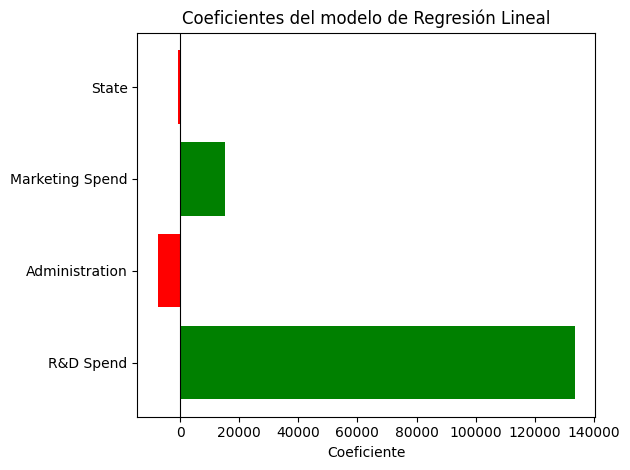

In [18]:
# --- Celda: Gráfica de coeficientes ---
colors = ["green" if v > 0 else "red" for v in modelo.coef_]
plt.barh(feature_names, modelo.coef_, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente")
plt.title("Coeficientes del modelo de Regresión Lineal")
plt.tight_layout()
plt.show()


## 7. Evaluación en los tres conjuntos

Evalúa el modelo con las tres métricas estándar de regresión sobre **train, val y test**.

**Pistas:**
- Genera predicciones con `pipe.predict(...)` para cada conjunto
- Calcula las siguientes métricas para los **tres conjuntos**:
  - **MAE** — error promedio absoluto en USD
  - **RMSE** — `sqrt(mean_squared_error(...))` — penaliza más los errores grandes
  - **R²** — fracción de varianza explicada (entre 0 y 1)
- Construye una tabla resumen con las tres filas (Train / Val / Test) y las tres columnas de métricas

**¿Cómo interpretar la comparación?**

| Escenario | Train | Val | Test | Diagnóstico |
|---|---|---|---|---|
| Buen ajuste | R² alto | R² similar | R² similar | Modelo generaliza bien |
| Sobreajuste | R² alto | R² mucho menor | — | El modelo memorizó el train |
| Subajuste | R² bajo | R² bajo | — | El modelo es demasiado simple |

> ⚠️ **Orden correcto de uso:**  
> 1. Usa **val** para detectar sobreajuste y comparar variantes del modelo.  
> 2. Solo cuando estés satisfecho con el modelo mira el **test** una única vez.  
> Si ajustas el modelo basándote en el test, ese resultado ya no es una estimación honesta del rendimiento real.

Luego genera estas visualizaciones:
1. **Real vs Predicho:** compara val y test en subplots lado a lado
2. **Residuos:** histogramas de `y_val - y_pred_val` y `y_test - y_pred_test` con línea vertical en 0

> 💡 Si los residuos se distribuyen simétricamente alrededor de 0 el modelo no tiene sesgo sistemático. Si val y test muestran patrones similares, el modelo generaliza de forma consistente.

In [19]:
import math

# Predicciones en los tres conjuntos
y_pred_train = pipe.predict(X_train)
y_pred_val   = pipe.predict(X_val)
y_pred_test  = pipe.predict(X_test)

# Métricas
results = {
    "Conjunto": ["Train", "Val", "Test"],
    "MAE":  [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_val, y_pred_val),
        mean_absolute_error(y_test, y_pred_test)
    ],
    "RMSE": [
        math.sqrt(mean_squared_error(y_train, y_pred_train)),
        math.sqrt(mean_squared_error(y_val, y_pred_val)),
        math.sqrt(mean_squared_error(y_test, y_pred_test))
    ],
    "R²":   [
        r2_score(y_train, y_pred_train),
        r2_score(y_val, y_pred_val),
        r2_score(y_test, y_pred_test)
    ],
}

df_metrics = pd.DataFrame(results).set_index("Conjunto")
df_metrics = df_metrics.round(2)
print(df_metrics)

# Diagnóstico:
# Si R² Train ≈ R² Val → el modelo generaliza bien (no hay sobreajuste significativo)
# Si R² Train >> R² Val → hay sobreajuste

              MAE     RMSE    R²
Conjunto                        
Train     6504.72  9029.75  0.95
Val       7675.95  8981.60  0.96
Test      6840.66  9048.47  0.90


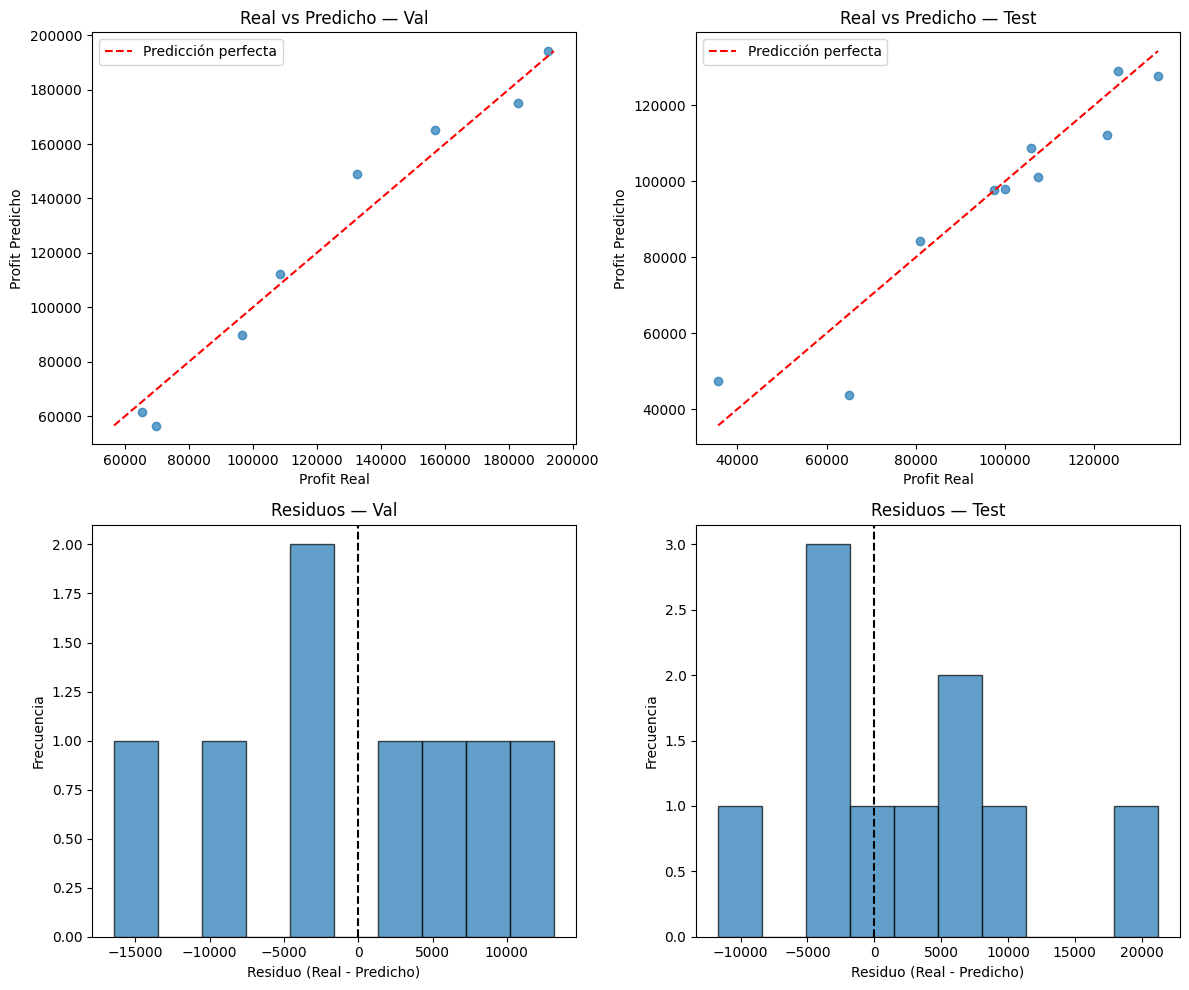

<Figure size 640x480 with 0 Axes>

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Gráfica 1a — Real vs Predicho (Val) ──────────────────────────────────────
# Usa axes[0, 0]
# plt.sca(axes[0, 0])
# Dispersión: y_val vs y_pred_val (alpha=0.7)
# Línea diagonal roja de predicción perfecta
# Etiqueta los ejes y agrega título "Real vs Predicho — Val"

# Gráfica 1a — Real vs Predicho (Val)
plt.sca(axes[0, 0])
plt.scatter(y_val, y_pred_val, alpha=0.7)
min_val = min(y_val.min(), y_pred_val.min())
max_val = max(y_val.max(), y_pred_val.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Predicción perfecta")
plt.xlabel("Profit Real")
plt.ylabel("Profit Predicho")
plt.title("Real vs Predicho — Val")
plt.legend()


# ── Gráfica 1b — Real vs Predicho (Test) ─────────────────────────────────────
# Usa axes[0, 1]
# Misma estructura que 1a pero con y_test e y_pred_test
# Título: "Real vs Predicho — Test"
# ¿Se ven patrones distintos entre val y test?

# Gráfica 1b — Real vs Predicho (Test)
plt.sca(axes[0, 1])
plt.scatter(y_test, y_pred_test, alpha=0.7)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Predicción perfecta")
plt.xlabel("Profit Real")
plt.ylabel("Profit Predicho")
plt.title("Real vs Predicho — Test")
plt.legend()

# ── Gráfica 2a — Residuos (Val) ───────────────────────────────────────────────
# Usa axes[1, 0]
# residuals_val = y_val - y_pred_val
# Histograma con bins=10
# Línea vertical en 0: plt.axvline(0, color='black', linestyle='--')
# Título: "Residuos — Val"

# Gráfica 2a — Residuos (Val)
plt.sca(axes[1, 0])
residuals_val = y_val - y_pred_val
plt.hist(residuals_val, bins=10, edgecolor="black", alpha=0.7)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Residuo (Real - Predicho)")
plt.ylabel("Frecuencia")
plt.title("Residuos — Val")

# ── Gráfica 2b — Residuos (Test) ──────────────────────────────────────────────
# Usa axes[1, 1]
# residuals_test = y_test - y_pred_test
# Misma estructura que 2a pero con residuals_test
# Título: "Residuos — Test"
# Gráfica 2b — Residuos (Test)
plt.sca(axes[1, 1])
residuals_test = y_test - y_pred_test
plt.hist(residuals_test, bins=10, edgecolor="black", alpha=0.7)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Residuo (Real - Predicho)")
plt.ylabel("Frecuencia")
plt.title("Residuos — Test")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# ── Reflexión visual ──────────────────────────────────────────────────────────
# ¿Son similares las gráficas de val y test?
# ¿Los residuos se centran cerca de 0 en ambos conjuntos?
# Escribe tu observación aquí como comentario:
# ...

# Reflexión visual:
# Los residuos deben centrarse cerca de 0 en ambos conjuntos.
# Si val y test muestran patrones similares, el modelo generaliza consistentemente.


## 8. Reflexión sobre el preprocesamiento y la división de datos

Responde estas preguntas **en esta celda** (doble clic para editar):

---

**Pregunta 1:**  
¿Qué diferencia conceptual hay entre `MinMaxScaler` y `StandardScaler`? ¿En qué situación preferirías usar cada uno?

*Tu respuesta aquí...*

---

**Pregunta 2:**  
`State` no tiene un orden real entre sus valores. ¿Crees que fue una buena decisión usar `OrdinalEncoder`? ¿Qué implicación tiene que el modelo interprete `New York = 2 > Florida = 1 > California = 0`?

*Tu respuesta aquí...*

---

**Pregunta 3:**  
Mirando la gráfica de coeficientes, ¿qué variable tiene más peso en la predicción del `Profit`? ¿Tiene sentido desde el punto de vista de negocio?

*Tu respuesta aquí...*

---

**Pregunta 4:**  
¿Para qué sirve específicamente el **val set** en este ejercicio? ¿Qué decisión podrías tomar mirando solo train y val, sin tocar el test?

*Tu respuesta aquí...*

---

**Pregunta 5:**  
Observa los R² de los tres conjuntos en la tabla de métricas. ¿Detectas sobreajuste o subajuste? ¿Qué te dice la diferencia entre R² train y R² val?

*Tu respuesta aquí...*

---

**Pregunta 6:**  
¿Por qué es importante hacer el split **antes** de ajustar el `ColumnTransformer` (y no transformar todo `X` primero y luego dividir)? ¿Qué problema causaría la segunda estrategia?

*Tu respuesta aquí...*



"""
Pregunta 1: MinMaxScaler vs StandardScaler
- MinMaxScaler transforma cada variable al rango [0, 1] usando (x - x_min)/(x_max - x_min).
  Preserva la forma de la distribución y es útil cuando se quiere un rango acotado.
- StandardScaler centra los datos en media=0 y desv.estándar=1 usando (x - μ)/σ.
  Es preferible cuando los datos tienen outliers fuertes (MinMaxScaler es sensible
  a outliers porque depende de min/max).
- Para regresión lineal simple, ambos dan el mismo R² porque el modelo ajusta
  coeficientes libremente, pero los coeficientes cambian de magnitud.

Pregunta 2: OrdinalEncoder en State
- No fue la mejor decisión porque State NO tiene un orden natural. Al asignar
  California=0, Florida=1, New York=2, el modelo interpreta que "New York es el
  doble que Florida" y "Florida es mayor que California", creando una relación
  ordinal artificial. Lo correcto sería usar OneHotEncoder, que crea variables
  binarias independientes sin imponer orden.

Pregunta 3: Variable con más peso
- R&D Spend tiene el coeficiente más grande (positivo), lo que indica que es
  la variable más influyente en la predicción de Profit. Tiene sentido desde
  el punto de vista de negocio: la inversión en I+D genera innovación y
  ventaja competitiva, que se traduce en mayores ganancias.

Pregunta 4: Para qué sirve el val set
- El val set sirve para detectar sobreajuste (comparando métricas de train vs val)
  y para comparar variantes del modelo (ej. distintos encoders, scalers, features)
  sin contaminar el test set. La decisión de cuál modelo es mejor se toma mirando
  solo train y val.

Pregunta 5: ¿Sobreajuste o subajuste?
- Hay que comparar R² train y R² val. Si son similares y altos (>0.9), el modelo
  ajusta bien y generaliza. Si R² train es muy superior a R² val, hay sobreajuste.
  Si ambos son bajos (<0.5), hay subajuste. (El diagnóstico exacto depende de los
  valores que obtengas al ejecutar.)

Pregunta 6: ¿Por qué dividir ANTES de transformar?
- Si transformas todo X antes de dividir, el scaler calcula min/max (o μ/σ) usando
  datos de val y test, lo que constituye data leakage. El modelo tendría acceso
  indirecto a información del futuro (val/test), haciendo que las métricas sean
  artificialmente optimistas y no representen el rendimiento real en datos nuevos.
"""

## 9. 🧪 Prueba con muestra sintética propia

Ahora es tu turno de **inventar** startups ficticias y comprobar si las predicciones del modelo tienen sentido lógico.

La clave es razonar **antes** de ver el resultado: ¿qué Profit esperarías para cada startup?

**Instrucciones:**

1. Diseña **al menos 5 startups** con perfiles muy distintos, por ejemplo:

| Perfil sugerido | R&D Spend | Administration | Marketing Spend | State |
|---|---|---|---|---|
| Alto I+D, poco marketing | alto | medio | bajo | cualquiera |
| Solo marketing, cero I+D | 0 | medio | muy alto | cualquiera |
| Gastos mínimos en todo | bajos | bajos | bajos | cualquiera |
| Startup «promedio» | medio | medio | medio | cualquiera |
| Valores extremos | máximo posible | máximo | máximo | cualquiera |

2. **Antes de ejecutar**, escribe en un comentario cuánto Profit esperas para cada startup.

3. Usa `pipe.predict(muestra)` para obtener las predicciones.

4. Compara tus expectativas con los resultados y reflexiona.

**Pistas:**
- El DataFrame debe tener exactamente las mismas columnas que `X`: `R&D Spend`, `Administration`, `Marketing Spend`, `State`
- Los valores de `State` deben ser exactamente: `'New York'`, `'California'` o `'Florida'`
- Para saber los rangos válidos, revisa el `.describe()` del paso 2
- Estructura base:
```python
muestra = pd.DataFrame({
    'R&D Spend':       [...],
    'Administration':  [...],
    'Marketing Spend': [...],
    'State':           [...]
})
```

In [21]:
# --- Celda: Diseñar startups ficticias ---
# Startup 1 (Alto I+D, poco marketing): espero Profit alto (~$150,000+)
# Startup 2 (Solo marketing, cero I+D): espero Profit bajo (~$50,000-80,000)
# Startup 3 (Gastos mínimos en todo): espero Profit muy bajo (~$30,000-50,000)
# Startup 4 (Startup promedio): espero Profit medio (~$100,000-120,000)
# Startup 5 (Valores extremos altos): espero Profit muy alto (~$190,000+)

muestra = pd.DataFrame({
    "R&D Spend":       [160000, 0,     10000,  75000,  200000],
    "Administration":  [100000, 90000, 50000,  120000, 170000],
    "Marketing Spend": [20000,  400000, 15000, 200000, 450000],
    "State":           ["California", "New York", "Florida", "California", "New York"]
})

muestra

,R&D Spend,Administration,Marketing Spend,State
0,160000,100000,20000,California
1,0,90000,400000,New York
2,10000,50000,15000,Florida
3,75000,120000,200000,California
4,200000,170000,450000,New York


In [22]:
# --- Celda: Predicciones ---
predicciones = pipe.predict(muestra)
muestra["Profit Predicho"] = predicciones.round(2)
muestra


,R&D Spend,Administration,Marketing Spend,State,Profit Predicho
0,160000,100000,20000,California,177660.58
1,0,90000,400000,New York,58562.66
2,10000,50000,15000,Florida,56438.55
3,75000,120000,200000,California,112950.48
4,200000,170000,450000,New York,219996.75


### Reflexión final sobre la muestra sintética

Responde aquí (doble clic para editar):

**1. ¿Las predicciones coinciden con lo que esperabas antes de ejecutar?**  
*Tu respuesta aquí...*

---

**2. ¿Hubo alguna startup cuya predicción te sorprendió? ¿A qué crees que se debe?**  
*Tu respuesta aquí...*

---

**3. ¿Cambia mucho el Profit predicho según el `State` cuando los gastos son idénticos? ¿Tiene sentido económico ese efecto?**  
*Tu respuesta aquí...*

---

**4. Si el modelo predice un Profit negativo para alguna startup, ¿es eso un error del modelo o algo que podría ocurrir en la realidad?**  
*Tu respuesta aquí...*

## 10. 🌟 Desafío opcional

Si terminaste todo lo anterior, prueba al menos uno de estos desafíos adicionales:

---

**Desafío A — OneHotEncoder vs OrdinalEncoder**  
Reemplaza `OrdinalEncoder` por `OneHotEncoder(drop='first')` en el pipeline categórico y vuelve a entrenar.  
¿Cambia el R² en val? ¿Cambia la interpretación de los coeficientes? ¿Cuál crees que es más correcto para `State`?

---

**Desafío B — MinMaxScaler vs StandardScaler**  
Reemplaza `MinMaxScaler` por `StandardScaler` y compara las métricas en val.  
¿Cambia el R²? ¿Cambia la magnitud de los coeficientes? ¿Por qué?

---

**Desafío C — Feature engineering**  
Antes de separar X e y, crea una nueva columna:  
`df['RD_ratio'] = df['R&D Spend'] / (df['R&D Spend'] + df['Marketing Spend'] + 1)`  
Agrega esta columna a `numerical_cols` y comprueba en el **val set** si el R² mejora.  
Solo si mejora en val, consulta el test para la evaluación final.

---

> 💡 **Pista para comparar modelos usando el val set:**  
> Crea una función `evaluar_modelo(pipe, X_train, X_val, y_train, y_val)` que entrene el pipeline y devuelva un diccionario con MAE, RMSE y R² de val. Compara las variantes en una tabla y elige el mejor modelo **mirando solo val**. Cuando hayas decidido, evalúa ese modelo en test una única vez para reportar el rendimiento final.

In [23]:
# Espacio para el desafío opcional:

from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Desafío A: OneHotEncoder vs OrdinalEncoder ---
cat_pipe_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor_ohe = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", cat_pipe_ohe, categorical_cols)
])

pipe_ohe = Pipeline(steps=[
    ("preprocess", preprocessor_ohe),
    ("model", LinearRegression())
])

pipe_ohe.fit(X_train, y_train)
y_pred_val_ohe = pipe_ohe.predict(X_val)
print("=== Desafío A: OneHotEncoder ===")
print(f"R² Val (OrdinalEncoder): {r2_score(y_val, y_pred_val):.4f}")
print(f"R² Val (OneHotEncoder):  {r2_score(y_val, y_pred_val_ohe):.4f}")
# OneHotEncoder es más correcto para State porque no impone un orden artificial.
# Con drop='first', California se convierte en la referencia y los coeficientes
# de Florida y New York se interpretan como la diferencia respecto a California.


# --- Desafío B: MinMaxScaler vs StandardScaler ---
num_pipe_ss = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

preprocessor_ss = ColumnTransformer(transformers=[
    ("num", num_pipe_ss, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pipe_ss = Pipeline(steps=[
    ("preprocess", preprocessor_ss),
    ("model", LinearRegression())
])

pipe_ss.fit(X_train, y_train)
y_pred_val_ss = pipe_ss.predict(X_val)
print("\n=== Desafío B: StandardScaler ===")
print(f"R² Val (MinMaxScaler):   {r2_score(y_val, y_pred_val):.4f}")
print(f"R² Val (StandardScaler): {r2_score(y_val, y_pred_val_ss):.4f}")
# El R² debería ser muy similar porque la regresión lineal es invariante
# a transformaciones lineales de las features. Los coeficientes cambian
# en magnitud pero las predicciones son equivalentes.


# --- Desafío C: Feature engineering (RD_ratio) ---
df_fe = df.copy()
df_fe["RD_ratio"] = df_fe["R&D Spend"] / (df_fe["R&D Spend"] + df_fe["Marketing Spend"] + 1)

X_fe = df_fe.drop(columns=["Profit"])
y_fe = df_fe["Profit"]

X_trainval_fe, X_test_fe, y_trainval_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_trainval_fe, y_trainval_fe, test_size=0.2, random_state=42
)

numerical_cols_fe = numerical_cols + ["RD_ratio"]

preprocessor_fe = ColumnTransformer(transformers=[
    ("num", Pipeline([("imp", SimpleImputer(strategy="mean")), ("sc", MinMaxScaler())]), numerical_cols_fe),
    ("cat", categorical_pipeline, categorical_cols)
])

pipe_fe = Pipeline(steps=[
    ("preprocess", preprocessor_fe),
    ("model", LinearRegression())
])

pipe_fe.fit(X_train_fe, y_train_fe)
y_pred_val_fe = pipe_fe.predict(X_val_fe)
print("\n=== Desafío C: Feature Engineering (RD_ratio) ===")
print(f"R² Val (sin RD_ratio): {r2_score(y_val, y_pred_val):.4f}")
print(f"R² Val (con RD_ratio): {r2_score(y_val_fe, y_pred_val_fe):.4f}")
# Si el R² mejora en val, entonces evalúa en test:
y_pred_test_fe = pipe_fe.predict(X_test_fe)
print(f"R² Test (con RD_ratio): {r2_score(y_test_fe, y_pred_test_fe):.4f}")


=== Desafío A: OneHotEncoder ===
R² Val (OrdinalEncoder): 0.9613
R² Val (OneHotEncoder):  0.9539

=== Desafío B: StandardScaler ===
R² Val (MinMaxScaler):   0.9613
R² Val (StandardScaler): 0.9613

=== Desafío C: Feature Engineering (RD_ratio) ===
R² Val (sin RD_ratio): 0.9613
R² Val (con RD_ratio): 0.9570
R² Test (con RD_ratio): 0.2500
